In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os

from utils.tools_optimize import TratamentoIniciaisDF# rodar_pipeline_completo
from modelagem_00 import *

In [9]:
path = rf"{os.getcwd()}\data\dados_anp_modelado.parquet"

df = pd.read_parquet(path.replace("\\src",''))

In [10]:
# A partir do df (antes das dummies), ou do df_train original antes do get_dummies
serie_sp_glp = (
    df[(df['Estado - Sigla'] == 'SP') & (df['Produto'] == 'GLP')]
    .set_index('dt_week')
    .sort_index()
)

y_treino = serie_sp_glp.loc[:'2025-04', 'price_sale_median']
y_val    = serie_sp_glp.loc['2025-05':'2025-08', 'price_sale_median']
y_teste  = serie_sp_glp.loc['2025-09':'2026-08', 'price_sale_median']

exog_treino = serie_sp_glp.loc[:'2025-04', ['Valor Venda Dolar', 'Close_BZ=F']]
exog_val    = serie_sp_glp.loc['2025-05':'2025-08', ['Valor Venda Dolar', 'Close_BZ=F']]
exog_teste  = serie_sp_glp.loc['2025-09':'2026-08', ['Valor Venda Dolar', 'Close_BZ=F']]

In [11]:
# %pip uninstall prophet pystan cmdstanpy -y
# %pip install cmdstanpy
# %pip install prophet

In [12]:
# pip install prophet --break-system-packages (se ainda não tiver)
from prophet import Prophet

df_prophet_treino = pd.DataFrame({
    'ds': y_treino.index.to_timestamp(),  # Prophet exige datetime, não Period
    'y': y_treino.values,
    'dolar': exog_treino['Valor Venda Dolar'].values,
    'brent': exog_treino['Close_BZ=F'].values,
})

df_prophet_val = pd.DataFrame({
    'ds': y_val.index.to_timestamp(),
    'dolar': exog_val['Valor Venda Dolar'].values,
    'brent': exog_val['Close_BZ=F'].values,
})

In [13]:
modelo_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,   # já é dado semanal, não faz sentido sazonalidade "por dia da semana"
    daily_seasonality=False,
    changepoint_prior_scale=0.05,  # controla flexibilidade da tendência (default razoável para começar)
)

modelo_prophet.add_regressor('dolar')
modelo_prophet.add_regressor('brent')

modelo_prophet.fit(df_prophet_treino)

DEBUG:cmdstanpy:cmd: where.exe tbb.dll
cwd: None
DEBUG:cmdstanpy:TBB already found in load path
DEBUG:cmdstanpy:input tempfile: C:\Users\ferna\AppData\Local\Temp\tmplcme2l7v\7jki0ezt.json
DEBUG:cmdstanpy:input tempfile: C:\Users\ferna\AppData\Local\Temp\tmplcme2l7v\znekq369.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['C:\\Users\\ferna\\anaconda3\\envs\\main\\Lib\\site-packages\\prophet\\stan_model\\prophet_model.bin', 'random', 'seed=39025', 'data', 'file=C:\\Users\\ferna\\AppData\\Local\\Temp\\tmplcme2l7v\\7jki0ezt.json', 'init=C:\\Users\\ferna\\AppData\\Local\\Temp\\tmplcme2l7v\\znekq369.json', 'output', 'file=C:\\Users\\ferna\\AppData\\Local\\Temp\\tmplcme2l7v\\prophet_modelun3r53nh\\prophet_model-20260907212336.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
21:23:36 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
21:23:37 - cmdstanpy - INFO - Chain [1] done processi

In [15]:
# Baseline "semana a semana": previsão da semana t = valor real da semana t-1
baseline_val = y_val.shift(1)
baseline_val.iloc[0] = y_treino.iloc[-1]  # primeira semana da validação usa o último valor do treino

mae_baseline_val_correto = (baseline_val - y_val).abs().mean()
print(f"MAE baseline (lag_1, validação): {mae_baseline_val_correto:.4f}")

MAE baseline (lag_1, validação): 1.2211


In [16]:
forecast_val = modelo_prophet.predict(df_prophet_val)
pred_val_prophet = forecast_val['yhat'].values

mae_prophet_val = mean_absolute_error(y_val.values, pred_val_prophet)

print(f"MAE baseline (lag_1):    {mae_baseline_val_correto:.4f}")
print(f"MAE Prophet (validação): {mae_prophet_val:.4f}")

melhora = (1 - mae_prophet_val / mae_baseline_val_correto) * 100
print(f"Melhora sobre baseline: {melhora:+.1f}%")

MAE baseline (lag_1):    1.2211
MAE Prophet (validação): 6.5469
Melhora sobre baseline: -436.1%


DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='c:\\Users\\ferna\\anaconda3\\envs\\main\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSans-Oblique.ttf', name='DejaVu Sans', style='oblique', variant='normal', weight=400, stretch='normal', size='scalable')) = 1.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='c:\\Users\\ferna\\anaconda3\\envs\\main\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSerif-BoldItalic.ttf', name='DejaVu Serif', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='c:\\Users\\ferna\\an

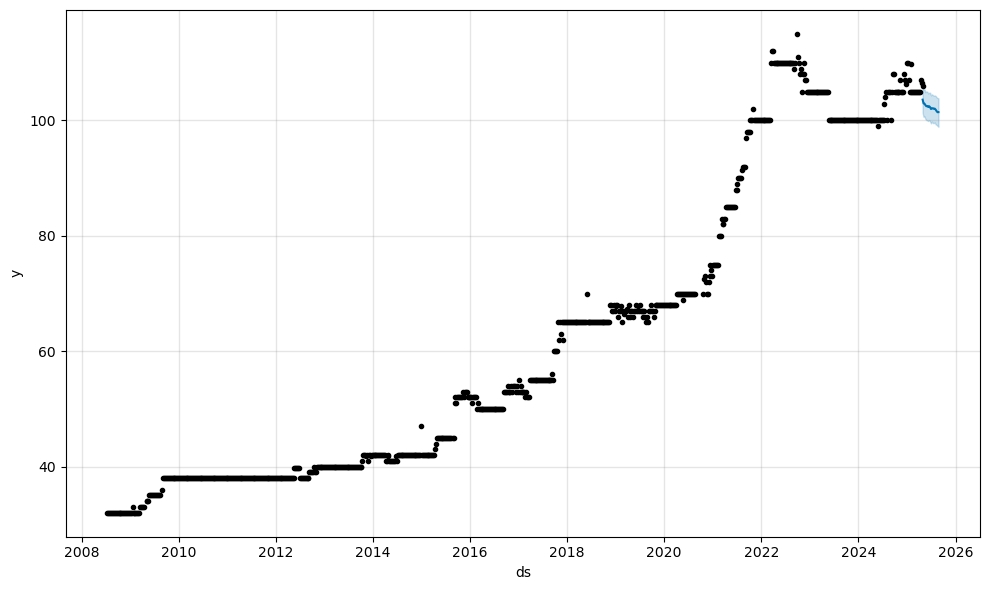

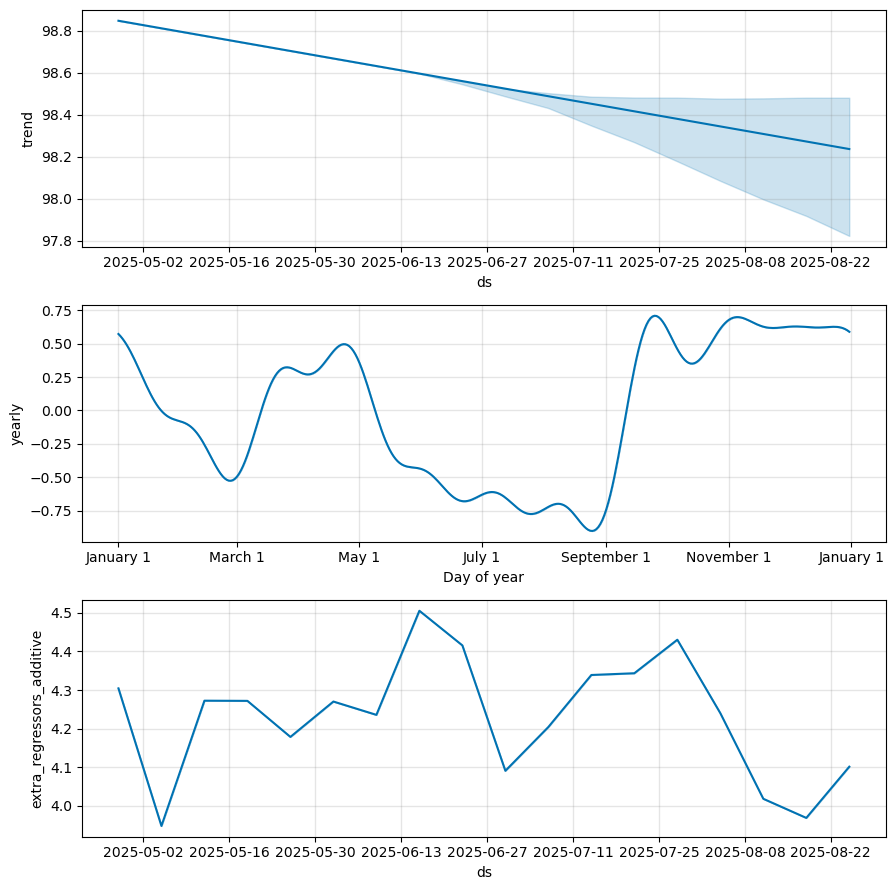

In [17]:
fig1 = modelo_prophet.plot(forecast_val)
fig2 = modelo_prophet.plot_components(forecast_val)

DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=12.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='c:\\Users\\ferna\\anaconda3\\envs\\main\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSans-Oblique.ttf', name='DejaVu Sans', style='oblique', variant='normal', weight=400, stretch='normal', size='scalable')) = 1.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='c:\\Users\\ferna\\anaconda3\\envs\\main\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSerif-BoldItalic.ttf', name='DejaVu Serif', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='c:\\Users\\ferna\\anaconda3\\envs\\main\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXGeneralBol.ttf', name='STIXGeneral', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')

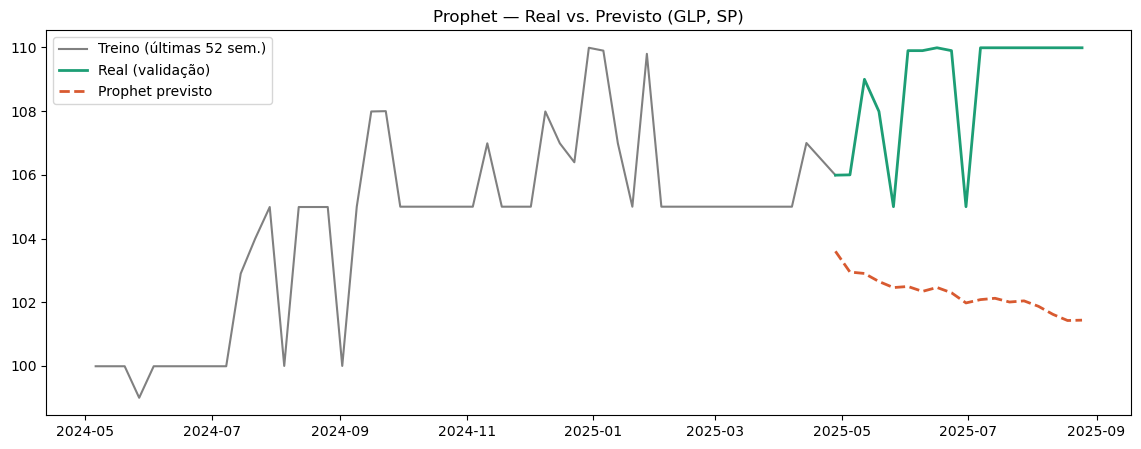

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_prophet_treino['ds'].tail(52), df_prophet_treino['y'].tail(52), label='Treino (últimas 52 sem.)', color='gray')
ax.plot(df_prophet_val['ds'], y_val.values, label='Real (validação)', color='#1D9E75', lw=2)
ax.plot(df_prophet_val['ds'], pred_val_prophet, label='Prophet previsto', color='#D85A30', lw=2, linestyle='--')
ax.legend()
ax.set_title('Prophet — Real vs. Previsto (GLP, SP)')
plt.show()

In [24]:
# Teste A: sem regressores exógenos, só tendência + sazonalidade
modelo_a = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
modelo_a.fit(df_prophet_treino[['ds', 'y']])
forecast_a = modelo_a.predict(df_prophet_val[['ds']])
mae_a = mean_absolute_error(y_val.values, forecast_a['yhat'].values)
print(f"MAE sem regressores: {mae_a:.4f}")

# Teste B: sem sazonalidade anual, com regressores
modelo_b = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
modelo_b.add_regressor('dolar')
modelo_b.add_regressor('brent')
modelo_b.fit(df_prophet_treino)
forecast_b = modelo_b.predict(df_prophet_val)
mae_b = mean_absolute_error(y_val.values, forecast_b['yhat'].values)
print(f"MAE sem sazonalidade anual: {mae_b:.4f}")

# Teste C: mínimo possível — só tendência
modelo_c = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
modelo_c.fit(df_prophet_treino[['ds', 'y']])
forecast_c = modelo_c.predict(df_prophet_val[['ds']])
mae_c = mean_absolute_error(y_val.values, forecast_c['yhat'].values)
print(f"MAE só tendência (sem sazonalidade, sem regressores): {mae_c:.4f}")

MAE sem regressores: 6.2017
MAE sem sazonalidade anual: 5.9669
MAE só tendência (sem sazonalidade, sem regressores): 5.7138


In [25]:
modelo_flex = Prophet(
    yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False,
    changepoint_prior_scale=0.5  # bem mais flexível que o default 0.05
)
modelo_flex.fit(df_prophet_treino[['ds', 'y']])
forecast_flex = modelo_flex.predict(df_prophet_val[['ds']])
mae_flex = mean_absolute_error(y_val.values, forecast_flex['yhat'].values)
print(f"MAE tendência flexível: {mae_flex:.4f}")

MAE tendência flexível: 6.3648


## Teste com Prophet — GLP em São Paulo (série piloto)

### Motivação

Terceira família de modelo testada, após árvores de decisão (seção anterior)
e SARIMAX. Prophet decompõe a série em tendência (linear por partes),
sazonalidade e regressores externos, com maior robustez a outliers do que
modelos ARIMA clássicos — hipótese a testar: essa decomposição explícita
lidaria melhor com a mudança de patamar identificada entre 2024 e 2025.

### Testes de isolamento (GLP, SP — validação: 2025-05 a 2025-08)

| Configuração | MAE |
|---|---|
| Completo (tendência + sazonalidade anual + regressores dólar/Brent) | 6.55 |
| Sem regressores exógenos | 6.20 |
| Sem sazonalidade anual | 5.97 |
| Só tendência (sem sazonalidade, sem regressores) | 5.71 |
| Tendência com flexibilidade máxima (`changepoint_prior_scale=0.5`) | 6.36 |
| **Baseline (`lag_1`)** | **1.22** |

### Diagnóstico

A inspeção visual (real vs. previsto) revelou a causa: no período de
validação, o preço real oscila em torno de um patamar relativamente estável
(~R$105–110), mas o Prophet projeta uma **tendência de queda linear
contínua**, extrapolada a partir da inclinação observada no fim do
treino. O erro se mantém alto em todas as variações testadas — incluindo a
versão mais simples possível (só tendência) e a versão com tendência
maximamente flexível — indicando que o problema não está em interações
entre componentes (sazonalidade, regressores), mas na própria natureza da
tendência linear por partes do Prophet, incompatível com o padrão real da
série: patamares de preço que mudam de forma abrupta e depois permanecem
estáveis, não uma tendência gradual e contínua.

### Conclusão

Prophet apresentou o pior desempenho entre as três famílias de modelo
testadas — entre 3.7x e 4.4x pior que o baseline, mesmo após tentativas de
ajuste (remoção de componentes, aumento de flexibilidade da tendência).

---

## Conclusão consolidada — três famílias de modelo testadas

| Família | Mecanismo | Resultado (GLP, SP) | Causa do fracasso |
|---|---|---|---|
| Árvores (XGBoost, LightGBM) | Splits binários por threshold | -3% a -38%¹ | Dificuldade de extrapolar além do range de valores observado no treino |
| SARIMAX | Estrutura linear autoregressiva | ~-95% | Resíduos fortemente não-normais e heterocedásticos; premissa de linearidade não se sustenta |
| Prophet | Tendência linear por partes + sazonalidade | -370% a -436% | Tendência linear incompatível com mudanças abruptas de patamar (padrão em degraus, não gradual) |
| **Baseline (`lag_1`)** | Persistência do último valor | referência | — |

¹ *Faixa observada nos 4 produtos, considerando as 8 combinações
algoritmo × segmentação testadas na seção anterior.*

**Nenhuma das três famílias de modelo testadas superou o baseline de
persistência.** Cada uma falhou por um motivo diagnosticado e distinto, o
que descarta a hipótese de que a limitação seria específica de uma técnica
ou implementação: é uma característica genuína da série. O preço semanal de
combustíveis no Brasil parece ser mais bem descrito como um processo de
persistência com saltos discretos e raros (mudanças tributárias, choques de
mercado, mudanças de política de preços) do que por qualquer estrutura
contínua — seja não-linear (árvores), linear autoregressiva (SARIMAX) ou de
tendência explícita (Prophet).

### Implicação prática

Para uma aplicação real de curto prazo (1 semana), o baseline de
persistência (`lag_1`) é a recomendação mais robusta e honesta,
eventualmente complementado por uma banda de incerteza calculada
empiricamente (ver seção de backtesting por horizonte), em vez de uma
previsão pontual de um modelo mais complexo que, apesar do esforço de
tuning e validação, não demonstrou vantagem preditiva nesta série.

### Trabalhos futuros

- Modelos híbridos que combinam a robustez do baseline com sinalização de
  risco de choque (ex.: usar a magnitude do resíduo previsto por um modelo
  de árvore como indicador de alerta, sem usar seu valor absoluto como
  previsão).
- Modelos de detecção de changepoint (ex.: PELT, Bayesian Online
  Changepoint Detection) para identificar de forma precoce o início de uma
  mudança de patamar, complementando — não substituindo — o baseline.
- Conformal prediction para construir intervalos de confiança com garantias
  formais de cobertura, a partir do erro histórico do próprio baseline.